# Regime-Aware Stock Return Prediction — Data Preprocessing


Core idea:

$
X_t = \text{information available at day } t
\quad \rightarrow \quad
y_t = r_{t+1}
$

The target is **next-day log return**, not raw price.


## 1. Imports and configuration

Run the install line only once if the packages are missing.


In [2]:
import sys
print(sys.executable)

d:\keras_env\.venv\Scripts\python.exe


In [3]:
# %pip install numpy pandas yfinance matplotlib 


In [ ]:

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt



pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_STATE = 5

tickers = ["AAPL", "MSFT", "IBM"]
start_date = "2010-01-01"
end_date = "2026-01-01"


## 2. Download daily OHLCV data

`auto_adjust=True` adjusts prices for splits and dividends, which is usually better for return modelling.


In [5]:
raw_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    group_by="ticker",
    progress=True
)

raw_data.head()


[*********************100%***********************]  3 of 3 completed


Ticker           MSFT                                                 AAPL                                                 IBM             \
Price            Open       High        Low      Close    Volume      Open      High       Low     Close     Volume       Open       High   
Date                                                                                                                                        
2010-01-04  22.781975  23.139105  22.759653  23.027502  38409100  6.389117  6.421148  6.357685  6.406480  493729600  71.249055  72.221275   
2010-01-05  22.953105  23.139111  22.796859  23.034946  49749600  6.424141  6.453777  6.383727  6.417555  601904800  71.520628  71.612965   
2010-01-06  22.975423  23.124228  22.707576  22.893581  58182400  6.417557  6.443002  6.308891  6.315477  552160000  70.977480  71.417426   
2010-01-07  22.789421  22.841504  22.462052  22.655499  50559700  6.338827  6.346311  6.258001  6.303802  477131200  70.537549  70.743942   
2010-01-08  22.529013  22.975425  22.499251  22.811741  51197400  6.295419  6.346310  6.258300  6.345711  447610800  70.103035  71.107842   

Ticker                                     
Price             Low      Close   Volume  
Date                                       
2010-01-04  71.069822  71.938843  6438444  
2010-01-05  70.662469  71.069824  7156104  
2010-01-06  70.504952  70.608147  5863144  
2010-01-07  70.016137  70.363747  6109268  
2010-01-08  70.092173  71.069824  4390271

In [6]:
raw_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4024 entries, 2010-01-04 to 2025-12-31
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (MSFT, Open)    4024 non-null   float64
 1   (MSFT, High)    4024 non-null   float64
 2   (MSFT, Low)     4024 non-null   float64
 3   (MSFT, Close)   4024 non-null   float64
 4   (MSFT, Volume)  4024 non-null   int64  
 5   (AAPL, Open)    4024 non-null   float64
 6   (AAPL, High)    4024 non-null   float64
 7   (AAPL, Low)     4024 non-null   float64
 8   (AAPL, Close)   4024 non-null   float64
 9   (AAPL, Volume)  4024 non-null   int64  
 10  (IBM, Open)     4024 non-null   float64
 11  (IBM, High)     4024 non-null   float64
 12  (IBM, Low)      4024 non-null   float64
 13  (IBM, Close)    4024 non-null   float64
 14  (IBM, Volume)   4024 non-null   int64  
dtypes: float64(12), int64(3)
memory usage: 503.0 KB


this confirms that therer re no null alues in those 15 columns

## 3. Convert yfinance output into a clean long table

The modelling table should have one row per `(Date, Ticker)`.


In [7]:
def yfinance_to_long(raw: pd.DataFrame, tickers: list[str]) -> pd.DataFrame:
    """Convert yfinance output into a long OHLCV table.

    Expected output columns:
    Date, Ticker, Open, High, Low, Close, Volume
    """
    frames = []

    if isinstance(raw.columns, pd.MultiIndex):
        level_0 = raw.columns.get_level_values(0)
        level_1 = raw.columns.get_level_values(1)

        for ticker in tickers:
            if ticker in level_0:
                tmp = raw[ticker].copy()
            elif ticker in level_1:
                tmp = raw.xs(ticker, axis=1, level=1).copy()
            else:
                raise ValueError(f"Ticker {ticker} was not found in yfinance output.")

            tmp = tmp.reset_index()
            tmp["Ticker"] = ticker
            frames.append(tmp)
    else:
        # This branch is useful if only one ticker is downloaded.
        tmp = raw.reset_index().copy()
        tmp["Ticker"] = tickers[0]
        frames.append(tmp)

    long_df = pd.concat(frames, ignore_index=True)

    # Keep only the columns needed for this project.
    required_cols = ["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]
    missing_cols = [col for col in required_cols if col not in long_df.columns]
    if missing_cols:
        raise ValueError(f"Missing expected columns: {missing_cols}")

    long_df = long_df[required_cols].copy()
    long_df["Date"] = pd.to_datetime(long_df["Date"])

    for col in ["Open", "High", "Low", "Close", "Volume"]:
        long_df[col] = pd.to_numeric(long_df[col], errors="coerce")

    long_df = long_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
    return long_df


prices = yfinance_to_long(raw_data, tickers)

print(prices.shape)
prices.head(10)


(12072, 7)


Price,Date,Ticker,Open,High,Low,Close,Volume
0,2010-01-04,AAPL,6.389117,6.421148,6.357685,6.406480,493729600
1,2010-01-05,AAPL,6.424141,6.453777,6.383727,6.417555,601904800
2,2010-01-06,AAPL,6.417557,6.443002,6.308891,6.315477,552160000
3,2010-01-07,AAPL,6.338827,6.346311,6.258001,6.303802,477131200
4,2010-01-08,AAPL,6.295419,6.346310,6.258300,6.345711,447610800
5,2010-01-11,AAPL,6.370260,6.376247,6.240041,6.289734,462229600
6,2010-01-12,AAPL,6.262192,6.279555,6.179271,6.218187,594459600
7,2010-01-13,AAPL,6.222677,6.314279,6.109820,6.305897,605892000
8,2010-01-14,AAPL,6.289732,6.300210,6.257102,6.269376,432894000
9,2010-01-15,AAPL,6.314279,6.334336,6.162806,6.164602,594067600


In [8]:
import sys
import sklearn
import pandas as pd
import yfinance as yf
import matplotlib

print(sys.executable)
print('scikit-learn:', sklearn.__version__)
print('pandas:', pd.__version__)
print('yfinance:', yf.__version__)
print('matplotlib:', matplotlib.__version__)

d:\keras_env\.venv\Scripts\python.exe
scikit-learn: 1.9.0
pandas: 3.0.3
yfinance: 1.4.1
matplotlib: 3.10.9


## 4. Create target and predictive features

The target is:

$\log(Close_t) - \log(Close_{t-1})
$
$
y_t = r_{t+1}
$

So each row at date `t` uses today's information to predict tomorrow's log return.


In [9]:
def add_stock_features(group: pd.DataFrame) -> pd.DataFrame:
    """Create return, volatility, momentum, volume, range, and drawdown features for one ticker."""
    ticker = group["Ticker"].iloc[0] if "Ticker" in group.columns else group.name
    g = group.sort_values("Date").copy()
    g["Ticker"] = ticker

    # Basic return target
    g["Log_Close"] = np.log(g["Close"])
    g["Log_Return"] = g["Log_Close"].diff()
    g["Simple_Return"] = g["Close"].pct_change()

    # Target_Date is the day being predicted.
    # Features at Date t are used to predict the return on Target_Date t+1.
    g["Target_Date"] = g["Date"].shift(-1)
    g["Next_Day_Log_Return"] = g["Log_Return"].shift(-1)

    # Direction target for classification-style evaluation.
    g["Direction_Target"] = np.where(g["Next_Day_Log_Return"] > 0, 1, 0)
    g.loc[g["Next_Day_Log_Return"].isna(), "Direction_Target"] = np.nan

    # Explicit bull/bear labels for regime analysis.
    # Binary version: 1 = bullish, 0 = bearish.
    g["Target_State_Binary"] = np.where(g["Next_Day_Log_Return"] > 0, 1, 0)
    g.loc[g["Next_Day_Log_Return"].isna(), "Target_State_Binary"] = np.nan

    # Text version for plots and interpretation.
    g["Target_State"] = np.where(
        g["Target_State_Binary"] == 1,
        "Bullish",
        "Bearish"
    )
    g.loc[g["Next_Day_Log_Return"].isna(), "Target_State"] = np.nan

    # Intraday/range features
    g["High_Low_Range"] = (g["High"] - g["Low"]) / g["Close"]
    g["Open_Close_Log_Return"] = np.log(g["Close"] / g["Open"])

    # Volume features
    g["Log_Volume"] = np.log(g["Volume"].replace(0, np.nan))
    g["Volume_Change"] = g["Log_Volume"].diff()

    # Rolling features. These only use past and current information.
    for window in [5, 10, 20, 60]:
        g[f"Rolling_Vol_{window}"] = g["Log_Return"].rolling(window).std()
        g[f"Momentum_{window}"] = g["Log_Return"].rolling(window).sum()
        g[f"MA_Gap_{window}"] = g["Close"] / g["Close"].rolling(window).mean() - 1

    # Drawdown over a recent window
    rolling_max_20 = g["Close"].rolling(20).max()
    g["Drawdown_20"] = g["Close"] / rolling_max_20 - 1

    return g

**Comments on the logic of this one:**
I added the boundary case: the split should be based on the target date: the target belongs to the next trading day, not to the current input day: for example: row 2020-12-31 may be training but its target s the return on the 1st trading day of 2021, which belongs to validation. 

- Logic: date = last observed day, target_date = dat being predicted, next_day_log_return = return on target date
- "Bull" and "Bear" state are strings: so for LSTM/classification/ regime evaluation, transferring this one to 1 and 0

In [10]:
features_raw = (
    prices
    .groupby("Ticker", group_keys=False)
    .apply(add_stock_features)
    .replace([np.inf, -np.inf], np.nan)
    .reset_index(drop=True)
)

print("prices columns:", prices.columns.tolist())
print("prices index names:", prices.index.names)
print("features_raw columns:", features_raw.columns.tolist())
print("features_raw index names:", features_raw.index.names)

features_raw.head()

prices columns: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']
prices index names: [None]
features_raw columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'Log_Close', 'Log_Return', 'Simple_Return', 'Target_Date', 'Next_Day_Log_Return', 'Direction_Target', 'Target_State_Binary', 'Target_State', 'High_Low_Range', 'Open_Close_Log_Return', 'Log_Volume', 'Volume_Change', 'Rolling_Vol_5', 'Momentum_5', 'MA_Gap_5', 'Rolling_Vol_10', 'Momentum_10', 'MA_Gap_10', 'Rolling_Vol_20', 'Momentum_20', 'MA_Gap_20', 'Rolling_Vol_60', 'Momentum_60', 'MA_Gap_60', 'Drawdown_20']
features_raw index names: [None]


Price,Date,Open,High,Low,Close,Volume,Ticker,Log_Close,Log_Return,Simple_Return,Target_Date,Next_Day_Log_Return,Direction_Target,Target_State_Binary,Target_State,High_Low_Range,Open_Close_Log_Return,Log_Volume,Volume_Change,Rolling_Vol_5,Momentum_5,MA_Gap_5,Rolling_Vol_10,Momentum_10,MA_Gap_10,Rolling_Vol_20,Momentum_20,MA_Gap_20,Rolling_Vol_60,Momentum_60,MA_Gap_60,Drawdown_20
0,2010-01-04,6.389117,6.421148,6.357685,6.406480,493729600,AAPL,1.857310,NaN,NaN,2010-01-05,0.001727,1.0,1.0,Bullish,0.009906,0.002714,20.017499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,6.424141,6.453777,6.383727,6.417555,601904800,AAPL,1.859037,0.001727,0.001729,2010-01-06,-0.016034,0.0,0.0,Bearish,0.010915,-0.001026,20.215610,0.198111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,6.417557,6.443002,6.308891,6.315477,552160000,AAPL,1.843003,-0.016034,-0.015906,2010-01-07,-0.001850,0.0,0.0,Bearish,0.021235,-0.016034,20.129348,-0.086261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,6.338827,6.346311,6.258001,6.303802,477131200,AAPL,1.841153,-0.001850,-0.001849,2010-01-08,0.006626,1.0,1.0,Bullish,0.014009,-0.005541,19.983302,-0.146046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,6.295419,6.346310,6.258300,6.345711,447610800,AAPL,1.847779,0.006626,0.006648,2010-01-11,-0.008860,0.0,0.0,Bearish,0.013869,0.007957,19.919435,-0.063867,NaN,NaN,-0.001902,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
target_col = "Next_Day_Log_Return"

feature_cols = [
    "Log_Return",
    "High_Low_Range",
    "Open_Close_Log_Return",
    "Volume_Change",
    "Rolling_Vol_5",
    "Rolling_Vol_10",
    "Rolling_Vol_20",
    "Rolling_Vol_60",
    "Momentum_5",
    "Momentum_10",
    "Momentum_20",
    "Momentum_60",
    "MA_Gap_5",
    "MA_Gap_10",
    "MA_Gap_20",
    "MA_Gap_60",
    "Drawdown_20",
]

# Keep rows where all modelling inputs and the target are known.
model_df = features_raw.dropna(
    subset=feature_cols + [target_col, "Target_Date"]
).copy()

model_df["Date"] = pd.to_datetime(model_df["Date"])
model_df["Target_Date"] = pd.to_datetime(model_df["Target_Date"])

for key in ["Ticker", "Date"]:
    if key not in model_df.columns and key in [name for name in model_df.index.names if name is not None]:
        model_df = model_df.reset_index()

missing_keys = [key for key in ["Ticker", "Date"] if key not in model_df.columns]
if missing_keys:
    raise KeyError(f"Missing required modelling keys: {missing_keys}. Available columns: {model_df.columns.tolist()}")

model_df = model_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Rows after preprocessing:", len(model_df))
print(model_df[["Ticker", "Date", "Close", "Log_Return", target_col]].head())

Rows after preprocessing: 11889
Price Ticker       Date     Close  Log_Return  Next_Day_Log_Return
0       AAPL 2010-03-31  7.034823   -0.003611             0.004120
1       AAPL 2010-04-01  7.063863    0.004120             0.010623
2       AAPL 2010-04-05  7.139302    0.010623             0.004393
3       AAPL 2010-04-06  7.170731    0.004393             0.004416
4       AAPL 2010-04-07  7.202464    0.004416            -0.002705


## 5. Quick sanity checks

These checks make sure the target alignment is correct:

- `Log_Return` on day `t` is today's return.
- `Next_Day_Log_Return` on day `t` is tomorrow's return.
- No target is computed from information before it exists.


In [12]:
for ticker in tickers:
    sample = model_df.loc[model_df["Ticker"] == ticker, ["Date", "Close", "Log_Return", "Next_Day_Log_Return", "Direction_Target", "Target_State"]].head(5)
    print(f"\n{ticker}")
    display(sample)



AAPL


Price,Date,Close,Log_Return,Next_Day_Log_Return,Direction_Target,Target_State
0,2010-03-31,7.034823,-0.003611,0.004120,1.0,Bullish
1,2010-04-01,7.063863,0.004120,0.010623,1.0,Bullish
2,2010-04-05,7.139302,0.010623,0.004393,1.0,Bullish
3,2010-04-06,7.170731,0.004393,0.004416,1.0,Bullish
4,2010-04-07,7.202464,0.004416,-0.002705,0.0,Bearish



MSFT


Price,Date,Close,Log_Return,Next_Day_Log_Return,Direction_Target,Target_State
7926,2010-03-31,21.894335,-0.016255,-0.004448,0.0,Bearish
7927,2010-04-01,21.797159,-0.004448,0.003765,1.0,Bullish
7928,2010-04-05,21.879387,0.003765,0.001706,1.0,Bullish
7929,2010-04-06,21.916756,0.001706,0.001023,1.0,Bullish
7930,2010-04-07,21.939184,0.001023,0.019234,1.0,Bullish



IBM


Price,Date,Close,Log_Return,Next_Day_Log_Return,Direction_Target,Target_State
3963,2010-03-31,69.969185,-0.004047,0.000000,0.0,Bearish
3964,2010-04-01,69.969185,0.000000,0.008541,1.0,Bullish
3965,2010-04-05,70.569328,0.008541,-0.003252,0.0,Bearish
3966,2010-04-06,70.340179,-0.003252,-0.003496,0.0,Bearish
3967,2010-04-07,70.094696,-0.003496,-0.006795,0.0,Bearish


In [13]:
summary = (
    model_df
    .groupby("Ticker")
    .agg(
        start=("Date", "min"),
        end=("Date", "max"),
        rows=("Date", "count"),
        mean_return=("Log_Return", "mean"),
        return_std=("Log_Return", "std"),
        target_mean=("Next_Day_Log_Return", "mean"),
        target_std=("Next_Day_Log_Return", "std"),
    )
)

summary


,start,end,rows,mean_return,return_std,target_mean,target_std
Ticker,,,,,,,
AAPL,2010-03-31,2025-12-30,3963,0.000922,0.017746,0.000922,0.017746
IBM,2010-03-31,2025-12-30,3963,0.000365,0.014434,0.000361,0.014437
MSFT,2010-03-31,2025-12-30,3963,0.000778,0.016108,0.000780,0.016106


## 6. Chronological train / validation / test split

For time-series data, never use a random split.

This first split is a simple fixed chronological split. Later modelling can use the walk-forward folds below.


In [14]:
train_end = pd.Timestamp("2020-12-31")
val_end = pd.Timestamp("2022-12-31")

def assign_split(date: pd.Timestamp) -> str:
    if date <= train_end:
        return "train"
    if date <= val_end:
        return "validation"
    return "test"

model_df["Split"] = model_df["Target_Date"].apply(assign_split)


split_summary = (
    model_df
    .groupby(["Ticker", "Split"])
    .agg(start=("Date", "min"), end=("Date", "max"), rows=("Date", "count"),
         # fixing the issue where a row at the end of the training may actually predict a validation-day return
         target_start =("Target_Date", "min"), target_end=("Target_Date", "max"))
)

split_summary


start        end  rows target_start target_end
Ticker Split                                                         
AAPL   test       2022-12-30 2025-12-30   752   2023-01-03 2025-12-31
       train      2010-03-31 2020-12-30  2708   2010-04-01 2020-12-31
       validation 2020-12-31 2022-12-29   503   2021-01-04 2022-12-30
IBM    test       2022-12-30 2025-12-30   752   2023-01-03 2025-12-31
       train      2010-03-31 2020-12-30  2708   2010-04-01 2020-12-31
       validation 2020-12-31 2022-12-29   503   2021-01-04 2022-12-30
MSFT   test       2022-12-30 2025-12-30   752   2023-01-03 2025-12-31
       train      2010-03-31 2020-12-30  2708   2010-04-01 2020-12-31
       validation 2020-12-31 2022-12-29   503   2021-01-04 2022-12-30

In [15]:
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)

model_df.to_parquet("outputs/model_df.parquet", index=False)

print("Saved model_df to outputs/model_df.parquet")
print("Shape:", model_df.shape)
print("Columns:", model_df.columns.tolist())

required_hmm_cols = [
    "Ticker",
    "Date",
    "Target_Date",
    "Split",
    "Log_Return",
    "Rolling_Vol_20",
    "Next_Day_Log_Return",
]

missing_cols = [col for col in required_hmm_cols if col not in model_df.columns]

if missing_cols:
    raise ValueError(f"Missing required HMM columns: {missing_cols}")

print("All required HMM columns are present.")

Saved model_df to outputs/model_df.parquet
Shape: (11889, 33)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'Log_Close', 'Log_Return', 'Simple_Return', 'Target_Date', 'Next_Day_Log_Return', 'Direction_Target', 'Target_State_Binary', 'Target_State', 'High_Low_Range', 'Open_Close_Log_Return', 'Log_Volume', 'Volume_Change', 'Rolling_Vol_5', 'Momentum_5', 'MA_Gap_5', 'Rolling_Vol_10', 'Momentum_10', 'MA_Gap_10', 'Rolling_Vol_20', 'Momentum_20', 'MA_Gap_20', 'Rolling_Vol_60', 'Momentum_60', 'MA_Gap_60', 'Drawdown_20', 'Split']
All required HMM columns are present.


## 7. Scaling without leakage

For LSTM training, features should be scaled.

Important rule:

$
\text{fit scaler on training data only}
$

Then apply the same scaler to validation and test data.


In [16]:
# MinMaxScaler maps features to [0, 1], which is common for LSTM inputs.
# StandardScaler is often useful for HMM/regime features later.
# lstm_scaler = MinMaxScaler()
# for financial returns, using the standard scaler seems more robust since most of my features are centered around 0
lstm_scaler = StandardScaler()   

train_mask = model_df["Split"] == "train"

scaled_feature_cols = [f"{col}_scaled" for col in feature_cols]

scaled_df = model_df.copy()
lstm_scaler.fit(scaled_df.loc[train_mask, feature_cols])

scaled_df[scaled_feature_cols] = lstm_scaler.transform(scaled_df[feature_cols])

scaled_df[["Ticker", "Date", "Split"] + scaled_feature_cols[:5] + [target_col]].head()


Price,Ticker,Date,Split,Log_Return_scaled,High_Low_Range_scaled,Open_Close_Log_Return_scaled,Volume_Change_scaled,Rolling_Vol_5_scaled,Next_Day_Log_Return
0,AAPL,2010-03-31,train,-0.265710,-0.772819,-0.194170,-0.593441,-0.067743,0.004120
1,AAPL,2010-04-01,train,0.213707,0.713186,-0.526932,0.989449,-0.476262,0.010623
2,AAPL,2010-04-05,train,0.617020,-0.173297,1.212256,0.372219,-0.671720,0.004393
3,AAPL,2010-04-06,train,0.230640,-0.371160,0.445653,-1.249806,-0.665153,0.004416
4,AAPL,2010-04-07,train,0.232064,-0.368989,0.342845,1.000902,-0.872417,-0.002705


In [17]:
# Check scaling range on the training set.
scaled_df.loc[train_mask, scaled_feature_cols].agg(["min", "max"]).T.head(20)


,min,max
Price,,
Log_Return_scaled,-9.930347,8.201890
High_Low_Range_scaled,-1.280367,20.374561
Open_Close_Log_Return_scaled,-6.287664,6.914400
Volume_Change_scaled,-4.857736,6.443960
Rolling_Vol_5_scaled,-1.333550,11.489319
Rolling_Vol_10_scaled,-1.409642,9.082315
Rolling_Vol_20_scaled,-1.472747,7.714211
Rolling_Vol_60_scaled,-1.535817,5.315155
Momentum_5_scaled,-6.895404,5.054153


## 8. Create LSTM sequences

The LSTM does not use single rows. It uses rolling windows:

$
[x_{t-L+1}, x_{t-L+2}, \ldots, x_t] \rightarrow r_{t+1}
$

The function below creates separate sequences for each ticker and each split, so sequences do not accidentally cross ticker boundaries.
*Caution when creating:* Making the sequences not too restrictive. Actually, make the validation/test sequences CAN USE the previous 60 days from the earlier split.


In [18]:
def make_lstm_sequences_by_target_split(
    df: pd.DataFrame,
    split: str,
    feature_columns: list[str],
    target_column: str,
    lookback: int = 60,
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Create LSTM sequences where the target row must belong to the requested split,
    but the input lookback window is allowed to use earlier historical rows.

    This is realistic because, when predicting a test-day return, past training/validation
    information is already known.
    """
    X, y, meta = [], [], []

    df = df.sort_values(["Ticker", "Date"]).copy()

    for ticker, g in df.groupby("Ticker"):
        g = g.sort_values("Date").reset_index(drop=True)

        values = g[feature_columns].to_numpy(dtype=np.float32)
        targets = g[target_column].to_numpy(dtype=np.float32)
        splits = g["Split"].to_numpy()
        input_dates = g["Date"].to_numpy()
        target_dates = g["Target_Date"].to_numpy()

        for idx in range(lookback - 1, len(g)):
            if splits[idx] != split:
                continue

            X.append(values[idx - lookback + 1:idx + 1])
            y.append(targets[idx])
            meta.append((ticker, input_dates[idx], target_dates[idx], splits[idx]))

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    meta = pd.DataFrame(
        meta,
        columns=["Ticker", "Input_End_Date", "Target_Date", "Split"]
    )

    return X, y, meta

In [19]:
#create sequences 
RUN_GLOBAL_SEQUENCE_CHECK = False

if RUN_GLOBAL_SEQUENCE_CHECK:
    lookback = 60

    X_train, y_train, meta_train = make_lstm_sequences_by_target_split(
        scaled_df, "train", scaled_feature_cols, target_col, lookback
    )

    X_val, y_val, meta_val = make_lstm_sequences_by_target_split(
        scaled_df, "validation", scaled_feature_cols, target_col, lookback
    )

    X_test, y_test, meta_test = make_lstm_sequences_by_target_split(
        scaled_df, "test", scaled_feature_cols, target_col, lookback
    )

    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val:", X_val.shape, "y_val:", y_val.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)

## 9. Walk-forward validation folds

This is the validation design for the final models.

Each fold trains on the past, validates on the next year, and tests on the following year.  
This respects the time order and avoids look-ahead bias.


In [20]:
def make_yearly_walk_forward_folds(
    df: pd.DataFrame,
    first_test_year: int = 2018,
    last_test_year: int = 2025,
) -> list[dict]:
    """Create expanding-window walk-forward folds by calendar year.

    For test year Y:
    - train: all observations before Y-1
    - validation: year Y-1
    - test: year Y
    """
    folds = []

    for test_year in range(first_test_year, last_test_year + 1):
        val_year = test_year - 1

        train_idx = df["Target_Date"].dt.year < val_year
        val_idx = df["Target_Date"].dt.year == val_year
        test_idx = df["Target_Date"].dt.year == test_year

        if train_idx.sum() == 0 or val_idx.sum() == 0 or test_idx.sum() == 0:
            continue

        folds.append(
            {
                "fold": len(folds) + 1,
                "train_idx": train_idx,
                "val_idx": val_idx,
                "test_idx": test_idx,
                "train_period": (df.loc[train_idx, "Target_Date"].min(), df.loc[train_idx, "Target_Date"].max()),
                "val_period": (df.loc[val_idx, "Target_Date"].min(), df.loc[val_idx, "Target_Date"].max()),
                "test_period": (df.loc[test_idx, "Target_Date"].min(), df.loc[test_idx, "Target_Date"].max()),
            }
        )

    return folds


folds = make_yearly_walk_forward_folds(model_df)

fold_overview = pd.DataFrame(
    [
        {
            "fold": f["fold"],
            "train_start": f["train_period"][0],
            "train_end": f["train_period"][1],
            "val_start": f["val_period"][0],
            "val_end": f["val_period"][1],
            "test_start": f["test_period"][0],
            "test_end": f["test_period"][1],
            "train_rows": int(f["train_idx"].sum()),
            "val_rows": int(f["val_idx"].sum()),
            "test_rows": int(f["test_idx"].sum()),
        }
        for f in folds
    ]
)

fold_overview


,fold,train_start,train_end,val_start,val_end,test_start,test_end,train_rows,val_rows,test_rows
0,1,2010-04-01,2016-12-30,2017-01-03,2017-12-29,2018-01-02,2018-12-31,5103,753,753
1,2,2010-04-01,2017-12-29,2018-01-02,2018-12-31,2019-01-02,2019-12-31,5856,753,756
2,3,2010-04-01,2018-12-31,2019-01-02,2019-12-31,2020-01-02,2020-12-31,6609,756,759
3,4,2010-04-01,2019-12-31,2020-01-02,2020-12-31,2021-01-04,2021-12-31,7365,759,756
4,5,2010-04-01,2020-12-31,2021-01-04,2021-12-31,2022-01-03,2022-12-30,8124,756,753
5,6,2010-04-01,2021-12-31,2022-01-03,2022-12-30,2023-01-03,2023-12-29,8880,753,750
6,7,2010-04-01,2022-12-30,2023-01-03,2023-12-29,2024-01-02,2024-12-31,9633,750,756
7,8,2010-04-01,2023-12-29,2024-01-02,2024-12-31,2025-01-02,2025-12-31,10383,756,750


## 10. Save preprocessed data

This saves the modelling table so the next notebook can start directly from cleaned features.


In [21]:
output_path = "preprocessed_stock_data.csv"
scaled_output_path = "preprocessed_stock_data_scaled.csv"

model_df.to_csv(output_path, index=False)
scaled_df.to_csv(scaled_output_path, index=False)

print(f"Saved unscaled modelling table to: {output_path}")
print(f"Saved scaled modelling table to:   {scaled_output_path}")


Saved unscaled modelling table to: preprocessed_stock_data.csv
Saved scaled modelling table to:   preprocessed_stock_data_scaled.csv


### Overview stocks of each:
SOme plots will be visulized here for the first outlook of the data

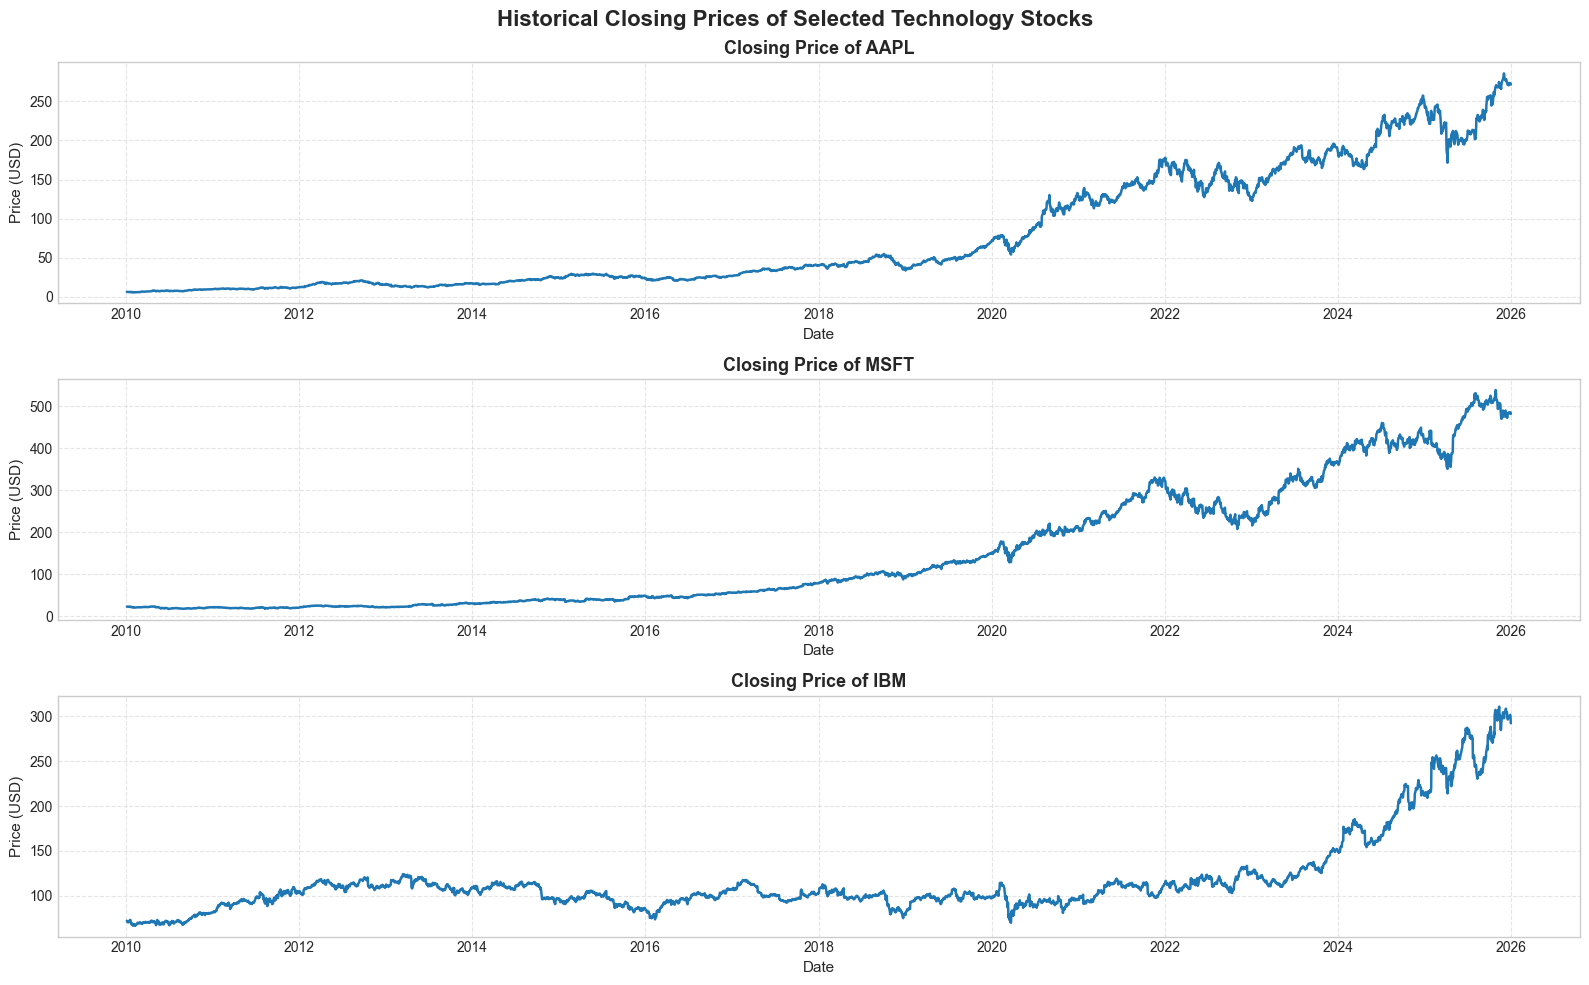

In [22]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(3, 1, figsize=(16, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    stock = features_raw[features_raw["Ticker"] == ticker]

    axes[i].plot(
        stock["Date"],
        stock["Close"],
        linewidth=1.8,
        color="tab:blue"
    )

    axes[i].set_title(f"Closing Price of {ticker}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Date", fontsize=11)
    axes[i].set_ylabel("Price (USD)", fontsize=11)
    axes[i].grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Historical Closing Prices of Selected Technology Stocks", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

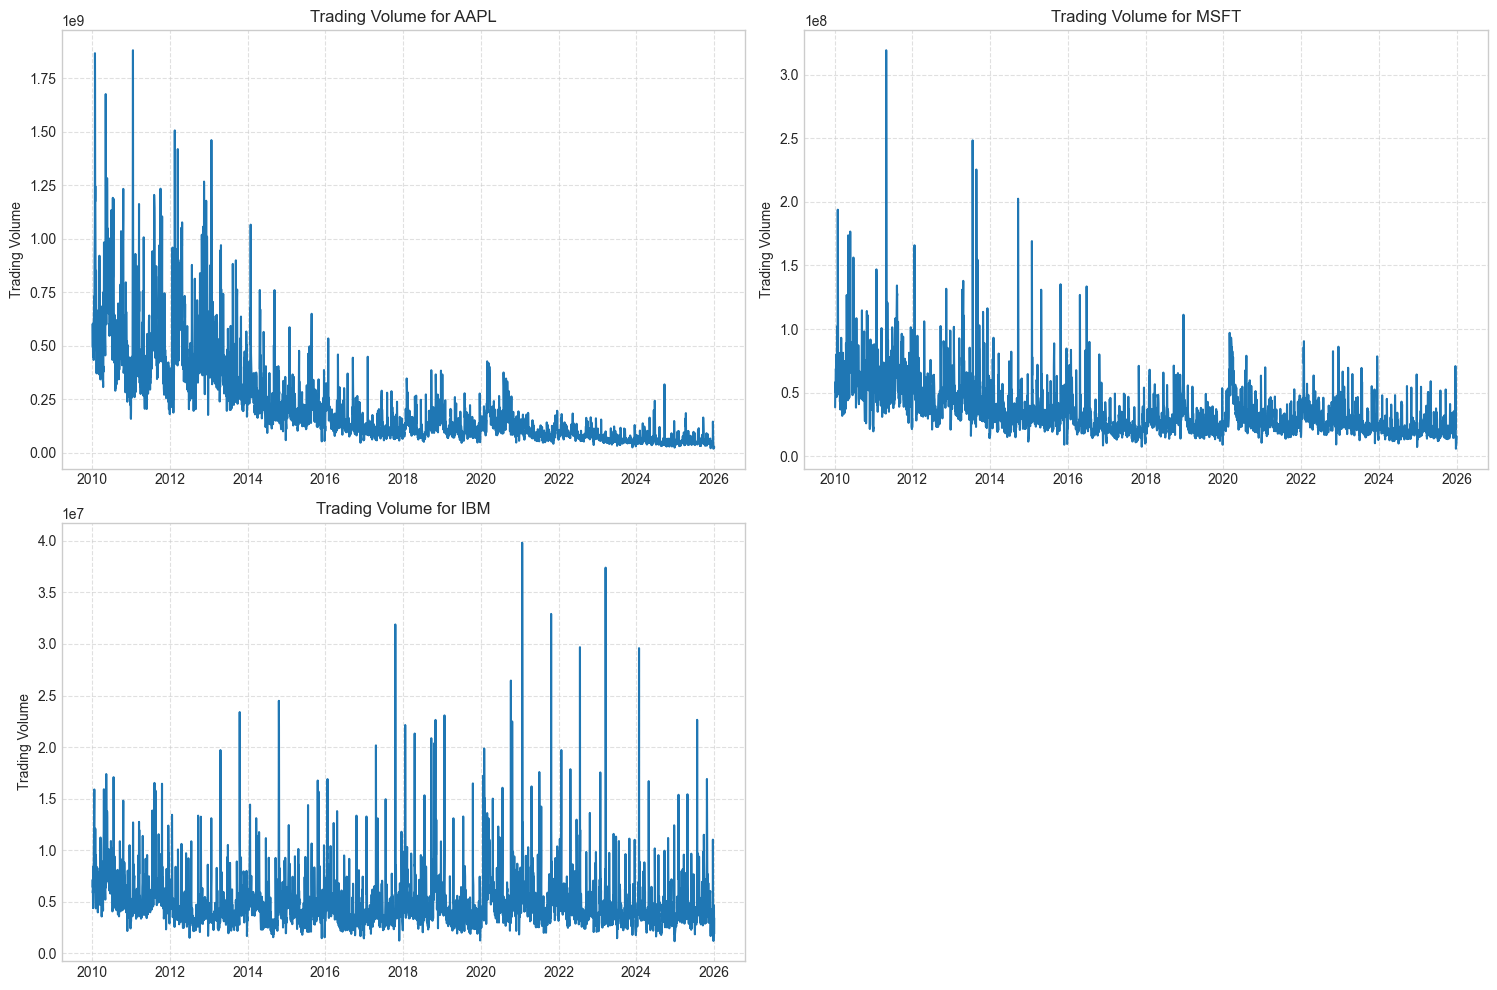

In [23]:
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, ticker in enumerate(tickers, 1):
    plt.subplot(2, 2, i)
    stock = features_raw[features_raw["Ticker"] == ticker]
    plt.plot(stock["Date"], stock["Volume"])
    plt.ylabel("Trading Volume")
    plt.xlabel("")
    plt.title(f"Trading Volume for {ticker}")
    plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

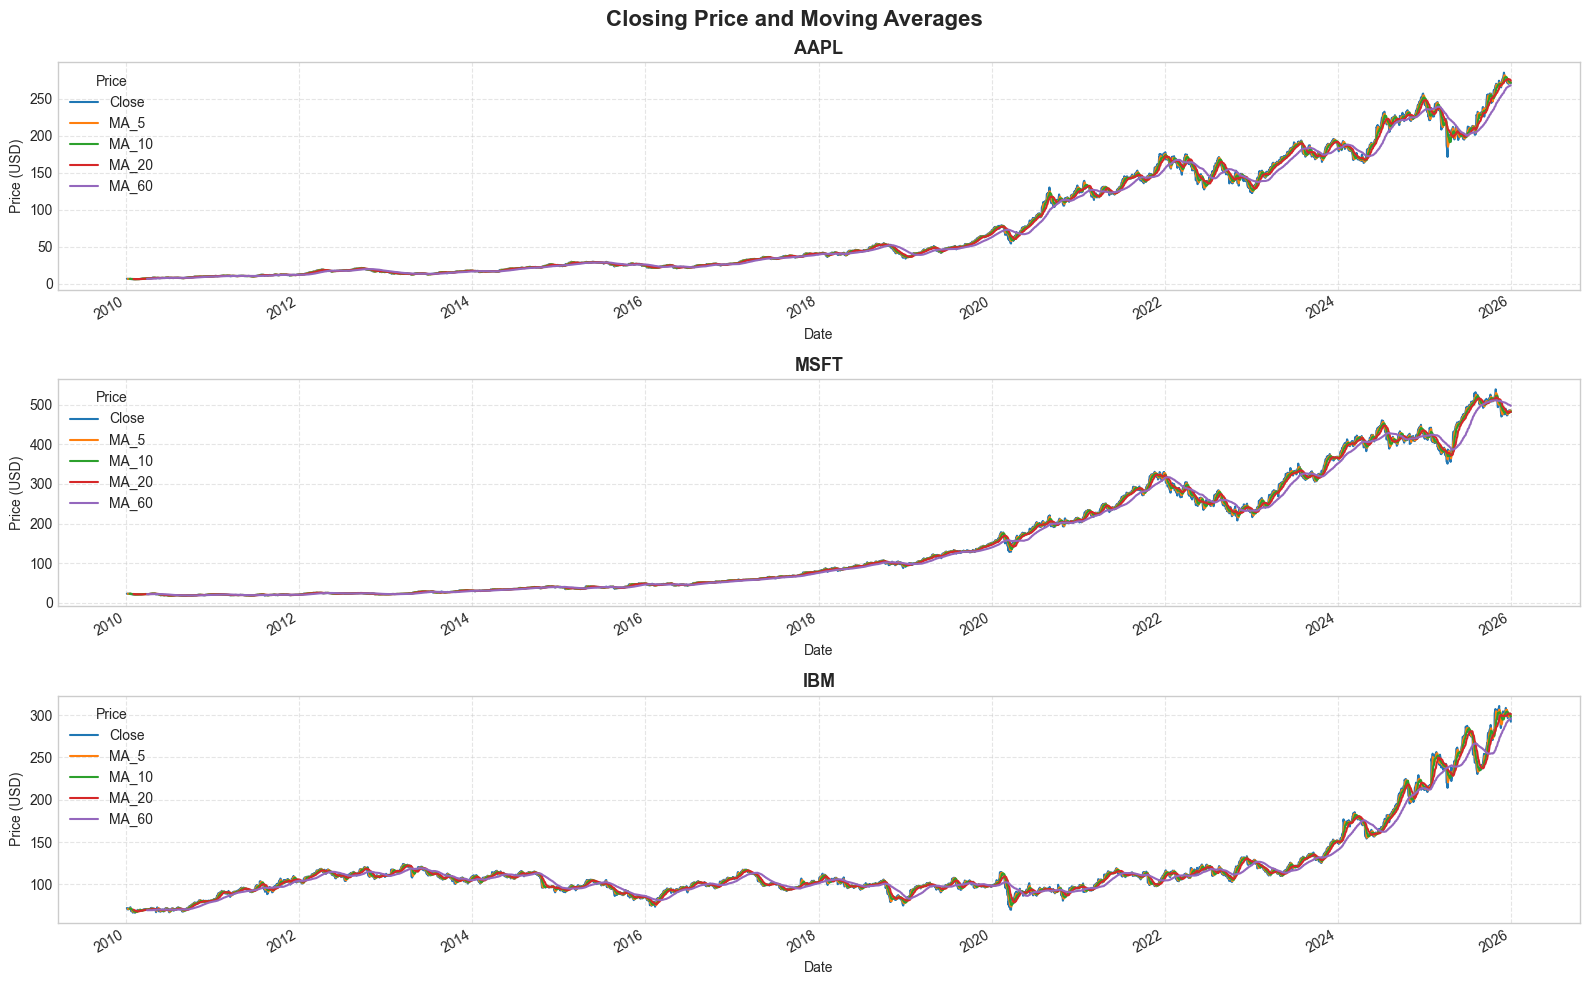

In [24]:
ma_days = [5, 10, 20, 60]

features_plot = features_raw.copy()

for ma in ma_days:
    features_plot[f"MA_{ma}"] = (
        features_plot
        .groupby("Ticker")["Close"]
        .transform(lambda x: x.rolling(ma).mean())
    )

fig, axes = plt.subplots(3, 1, figsize=(16, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    stock = features_plot[features_plot["Ticker"] == ticker]

    stock[["Close", "MA_5", "MA_10", "MA_20", "MA_60"]].set_index(stock["Date"]).plot(ax=axes[i], linewidth=1.5)

    axes[i].set_title(f"{ticker}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Price (USD)")
    axes[i].grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Closing Price and Moving Averages", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()




## Optional pooled LSTM baseline ? disabled for main analysis

This pooled model is kept only as a robustness check. The main analysis uses separate models per ticker because each stock can have different return, volatility, and regime dynamics.


In [25]:
RUN_POOLED_MODEL = False


In [26]:
if RUN_POOLED_MODEL:
    from lstm_architecture import (
        set_global_seed,
        build_baseline_lstm,
        build_bigger_lstm,
        get_training_callbacks,
        evaluate_regression,

    )

    set_global_seed(5)

In [27]:
if RUN_POOLED_MODEL:
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("X_val:", X_val.shape)
    print("y_val:", y_val.shape)

In [28]:
if RUN_POOLED_MODEL:
    model = build_baseline_lstm(
        input_shape=(X_train.shape[1], X_train.shape[2])
    )

    model.summary()

In [29]:
if RUN_POOLED_MODEL:
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=get_training_callbacks(
            model_path="models/baseline_lstm.keras",
            patience=10
        ),
        verbose=1,
        shuffle=False
    )

In [30]:
if RUN_POOLED_MODEL:
    y_pred = model.predict(X_test)
    metrics = evaluate_regression(y_test, y_pred)
    metrics

### Scatter plot for the predicted $\hat{y}$ and real $y$:


In [31]:
if RUN_POOLED_MODEL:
    plt.scatter(y_test, y_pred)
    lims = [min(y_test.min(), y_pred.min()),
            max(y_test.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--')
    plt.xlabel("Actual Next Day Log Return")
    plt.ylabel("Predicted Next Day Log Return")
    plt.title("Baseline LSTM: Actual vs Predicted Next Day Log Returns")
    plt.show()

In [32]:
if RUN_POOLED_MODEL:
    from plot_helpers import plot_actual_vs_predicted_returns
    plot_actual_vs_predicted_returns(y_test, y_pred)

from the plots, and the statistics, it's clear that the model LSTM, is underfitting. It learned the safe answer, which is always return the next day log return to be $\approx$ 0

In [33]:
if RUN_POOLED_MODEL:
    print("Actual mean:", y_test.mean())
    print("Actual std :", y_test.std())

    print("Pred mean :", y_pred.mean())
    print("Pred std  :", y_pred.std())

    print("Actual min/max:", y_test.min(), y_test.max())
    print("Pred min/max  :", y_pred.min(), y_pred.max())

Finally, it's clear that the model learn the safe way( returning 0), it basically returns one constant value for each sample. Hence it's clear that it's time to tune the models.


In [ ]:
if RUN_POOLED_MODEL:
    #trying stronger moddel:
    # scalling target y

    

    y_scaler = StandardScaler()

    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
    y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

In [35]:
if RUN_POOLED_MODEL:
    from lstm_architecture import build_lstm_model, LSTMConfig
    config = LSTMConfig(
        lstm_units=(64, 32),
        dense_units=(16,),
        dropout=0.10,
        recurrent_dropout=0.0,
        learning_rate=1e-3,
        loss="mse",
        output_units=1,
    )

    model_new = build_lstm_model(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        config=config
    )

    model_new.summary()

    history = model_new.fit(
        X_train,
        y_train_scaled,
        validation_data=(X_val, y_val_scaled),
        epochs=100,
        batch_size=32,
        callbacks=get_training_callbacks(
            model_path="models/lstm_scaled_y_low_dropout.keras",
            patience=15
        ),  
        verbose=1,
        shuffle=False
    )

In [36]:
if RUN_POOLED_MODEL:
    y_pred_scaled = model_new.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(np.asarray(y_pred_scaled).reshape(-1, 1)).ravel()

    print("Actual std:", y_test.std())
    print("Pred std :", y_pred.std())
    print("Pred min/max:", y_pred.min(), y_pred.max())

In [37]:
if RUN_POOLED_MODEL:
    plot_actual_vs_predicted_returns(y_test, y_pred)

In [38]:
if RUN_POOLED_MODEL:
    plt.figure(figsize=(12, 4))
    plt.plot(y_pred[:300], label="Predicted returns")
    plt.legend()
    plt.title("Predicted Returns Only")
    plt.show()

In [39]:
if RUN_POOLED_MODEL:
    print("Share of actual positive returns:", np.mean(y_test > 0))
    print("Share of predicted positive returns:", np.mean(y_pred > 0))
    print("Pred min/max:", y_pred.min(), y_pred.max())

## Main modelling route: separate model per ticker


### Why separate-stock models?

A pooled LSTM can collapse toward the cross-sectional mean when it sees sequences from different stocks without an explicit ticker identity feature.
The block below keeps the same engineered inputs, trains one model per stock with a 60-day lookback, and scales the target separately for each stock so we can check whether the collapse is mainly caused by pooling.

In [40]:
from sklearn.preprocessing import StandardScaler
from lstm_architecture import LSTMConfig, build_lstm_model, get_training_callbacks, evaluate_regression


def scale_single_ticker_features(
    single_stock_df: pd.DataFrame,
    feature_cols: list[str],
    split_col: str = "Split",
) -> tuple[pd.DataFrame, list[str], StandardScaler]:
    """Fit feature scaling on one ticker's training rows and transform all splits."""
    single_stock_df = single_stock_df.copy()
    train_mask = single_stock_df[split_col] == "train"
    if not train_mask.any():
        raise ValueError("No training rows available for ticker-specific feature scaling.")

    scaler = StandardScaler()
    scaled_feature_cols = [f"{col}_scaled" for col in feature_cols]
    scaler.fit(single_stock_df.loc[train_mask, feature_cols])
    single_stock_df[scaled_feature_cols] = scaler.transform(single_stock_df[feature_cols])
    return single_stock_df, scaled_feature_cols, scaler


def train_single_stock_lstm(
    model_df: pd.DataFrame,
    ticker: str,
    feature_cols: list[str],
    target_col: str,
    lookback: int = 60,
    epochs: int = 100,
    batch_size: int = 32,
    patience: int = 15,
):
    single_stock_df = model_df.loc[model_df["Ticker"] == ticker].copy()
    if single_stock_df.empty:
        raise ValueError(f"No rows found for ticker {ticker}.")

    single_stock_df, scaled_feature_cols_s, feature_scaler_s = scale_single_ticker_features(
        single_stock_df,
        feature_cols,
    )

    X_train_s, y_train_s, meta_train_s = make_lstm_sequences_by_target_split(
        single_stock_df, "train", scaled_feature_cols_s, target_col, lookback
    )
    X_val_s, y_val_s, meta_val_s = make_lstm_sequences_by_target_split(
        single_stock_df, "validation", scaled_feature_cols_s, target_col, lookback
    )
    X_test_s, y_test_s, meta_test_s = make_lstm_sequences_by_target_split(
        single_stock_df, "test", scaled_feature_cols_s, target_col, lookback
    )

    if min(len(y_train_s), len(y_val_s), len(y_test_s)) == 0:
        raise ValueError(
            f"{ticker}: one of the splits has zero sequences. "
            f"train={len(y_train_s)}, val={len(y_val_s)}, test={len(y_test_s)}"
        )

    y_scaler_s = StandardScaler()
    y_train_s_scaled = y_scaler_s.fit_transform(y_train_s.reshape(-1, 1)).ravel()
    y_val_s_scaled = y_scaler_s.transform(y_val_s.reshape(-1, 1)).ravel()

    config = LSTMConfig(
        lstm_units=(32,),
        dense_units=(16,),
        dropout=0.10,
        recurrent_dropout=0.0,
        learning_rate=1e-3,
        loss="mse",
        output_units=1,
    )

    model_s = build_lstm_model(
        input_shape=(X_train_s.shape[1], X_train_s.shape[2]),
        config=config,
    )

    history_s = model_s.fit(
        X_train_s,
        y_train_s_scaled,
        validation_data=(X_val_s, y_val_s_scaled),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=get_training_callbacks(
            model_path=f"models/lstm_{ticker}.keras",
            patience=patience,
        ),
        verbose=1,
        shuffle=True,
    )

    y_val_pred_scaled = model_s.predict(X_val_s, verbose=0)
    y_val_pred = y_scaler_s.inverse_transform(
        np.asarray(y_val_pred_scaled).reshape(-1, 1)
    ).ravel()

    y_pred_scaled = model_s.predict(X_test_s, verbose=0)
    y_pred_s = y_scaler_s.inverse_transform(
        np.asarray(y_pred_scaled).reshape(-1, 1)
    ).ravel()

    metrics_s = evaluate_regression(y_test_s, y_pred_s)
    diagnostics_s = {
        "ticker": ticker,
        "lookback": lookback,
        "train_rows": int((single_stock_df["Split"] == "train").sum()),
        "val_rows": int((single_stock_df["Split"] == "validation").sum()),
        "test_rows": int((single_stock_df["Split"] == "test").sum()),
        "train_sequences": int(len(y_train_s)),
        "val_sequences": int(len(y_val_s)),
        "test_sequences": int(len(y_test_s)),
        "train_mean_return": float(y_train_s.mean()),
        "val_actual_std": float(y_val_s.std()),
        "test_actual_std": float(y_test_s.std()),
        "val_pred_std": float(y_val_pred.std()),
        "pred_std": float(y_pred_s.std()),
        "share_actual_positive": float(np.mean(y_test_s > 0)),
        "share_pred_positive": float(np.mean(y_pred_s > 0)),
    }

    def build_prediction_frame(meta_df: pd.DataFrame, y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
        pred_df = meta_df.rename(
            columns={
                "Ticker": "ticker",
                "Input_End_Date": "input_end_date",
                "Target_Date": "target_date",
                "Split": "split",
            }
        ).copy()
        pred_df["y_true"] = y_true
        pred_df["y_pred"] = y_pred
        pred_df["model"] = "baseline_lstm"
        pred_df["ticker"] = ticker
        return pred_df

    val_predictions = build_prediction_frame(meta_val_s, y_val_s, y_val_pred)
    test_predictions = build_prediction_frame(meta_test_s, y_test_s, y_pred_s)
    predictions = pd.concat([val_predictions, test_predictions], ignore_index=True)

    print(f"Ticker: {ticker}")
    print(f"Validation sequences: {len(y_val_s)} | Test sequences: {len(y_test_s)}")
    print(f"Validation pred std: {diagnostics_s['val_pred_std']:.6f}")
    print(f"Test pred std      : {diagnostics_s['pred_std']:.6f}")

    return {
        "ticker": ticker,
        "model": model_s,
        "history": history_s,
        "feature_scaler": feature_scaler_s,
        "scaled_feature_cols": scaled_feature_cols_s,
        "y_scaler": y_scaler_s,
        "X_train": X_train_s,
        "X_val": X_val_s,
        "X_test": X_test_s,
        "y_train": y_train_s,
        "y_val": y_val_s,
        "y_test": y_test_s,
        "y_val_pred": y_val_pred,
        "y_pred": y_pred_s,
        "metrics": metrics_s,
        "diagnostics": diagnostics_s,
        "predictions": predictions,
        "metadata": {
            "train": meta_train_s,
            "validation": meta_val_s,
            "test": meta_test_s,
        },
    }


In [41]:
single_stock_runs = {}
single_stock_rows = []

for ticker in tickers:
    run = train_single_stock_lstm(
        model_df=model_df,
        ticker=ticker,
        feature_cols=feature_cols,
        target_col=target_col,
        lookback=60,
    )
    single_stock_runs[ticker] = run

    row = {"ticker": ticker, "model": "baseline_lstm"}
    row.update(run["metrics"])
    row.update(run["diagnostics"])
    single_stock_rows.append(row)


Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 1.0512 - mae: 0.7147 - val_loss: 1.2071 - val_mae: 0.8431 - learning_rate: 0.0010
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.0174 - mae: 0.7028 - val_loss: 1.1926 - val_mae: 0.8398 - learning_rate: 0.0010
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.0031 - mae: 0.6982 - val_loss: 1.2134 - val_mae: 0.8503 - learning_rate: 0.0010
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.9851 - mae: 0.6927 - val_loss: 1.2095 - val_mae: 0.8490 - learning_rate: 0.0010
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.9952 - mae: 0.6929 - val_loss: 1.2070 - val_mae: 0.8478 - learning_rate: 0.0010
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.9851 - mae: 0.6940 - val_loss: 1.2070 - val_mae: 0.8466 - learning_rate: 0.0010
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.9778 - mae: 0.6925 - val_loss: 1.1989 - val_mae: 0.8446 - learning_rate: 0.0010
Epoch 

In [42]:
single_stock_results_df = (
    pd.DataFrame(single_stock_rows)
    .sort_values("ticker")
    .reset_index(drop=True)
)

single_stock_results_df


,ticker,model,mse,rmse,mae,r2,direction_accuracy,lookback,train_rows,val_rows,test_rows,train_sequences,val_sequences,test_sequences,train_mean_return,val_actual_std,test_actual_std,val_pred_std,pred_std,share_actual_positive,share_pred_positive
0,AAPL,baseline_lstm,0.000263,0.016226,0.011123,-0.019385,0.515957,60,2708,503,752,2649,503,752,0.001047,0.019405,0.016071,0.002281,0.001999,0.549202,0.775266
1,IBM,baseline_lstm,0.000227,0.015056,0.010098,-0.018638,0.480053,60,2708,503,752,2649,503,752,0.000120,0.014803,0.014918,0.001659,0.001868,0.562500,0.405585
2,MSFT,baseline_lstm,0.000220,0.014844,0.010684,-0.041888,0.507979,60,2708,503,752,2649,503,752,0.000916,0.018324,0.014542,0.003586,0.002646,0.542553,0.614362


## 13. Benchmark comparison

Compare each ticker-specific LSTM against zero-return and train-mean-return baselines on the test split.


In [43]:
from pathlib import Path
import importlib.util

benchmark_rows = []
prediction_frames = []

for ticker in tickers:
    run = single_stock_runs[ticker]
    y_test_t = run["y_test"]
    y_train_t = run["y_train"]

    zero_pred = np.zeros_like(y_test_t)
    train_mean_pred = np.full_like(y_test_t, y_train_t.mean(), dtype=np.float32)

    benchmark_rows.append({
        "ticker": ticker,
        "model": "zero_return",
        **evaluate_regression(y_test_t, zero_pred),
    })
    benchmark_rows.append({
        "ticker": ticker,
        "model": "train_mean_return",
        **evaluate_regression(y_test_t, train_mean_pred),
    })
    benchmark_rows.append({
        "ticker": ticker,
        "model": "baseline_lstm",
        **run["metrics"],
    })

    prediction_frames.append(run["predictions"])

single_stock_benchmark_df = (
    pd.DataFrame(benchmark_rows)
    .sort_values(["ticker", "model"])
    .reset_index(drop=True)
)

baseline_lstm_predictions_all_tickers = (
    pd.concat(prediction_frames, ignore_index=True)
    .sort_values(["ticker", "split", "target_date"])
    .reset_index(drop=True)
)

metrics_dir = Path("outputs/metrics")
predictions_dir = Path("outputs/predictions")
metrics_dir.mkdir(parents=True, exist_ok=True)
predictions_dir.mkdir(parents=True, exist_ok=True)

single_stock_results_df.to_csv(
    metrics_dir / "single_stock_lstm_metrics.csv",
    index=False,
)
single_stock_benchmark_df.to_csv(
    metrics_dir / "single_stock_benchmark_metrics.csv",
    index=False,
)

parquet_path = predictions_dir / "baseline_lstm_predictions_all_tickers.parquet"
if importlib.util.find_spec("pyarrow") is None:
    raise RuntimeError(
        "pyarrow is required for parquet export. Install it in the active kernel, restart the kernel, and rerun this cell."
    )

baseline_lstm_predictions_all_tickers.to_parquet(
    parquet_path,
    index=False,
    engine="pyarrow",
)

print(single_stock_benchmark_df)
print(f"Saved metrics to {metrics_dir}")
print(f"Saved predictions to {parquet_path}")


  ticker              model       mse      rmse       mae        r2  direction_accuracy
0   AAPL      baseline_lstm  0.000263  0.016226  0.011123 -0.019385            0.515957
1   AAPL  train_mean_return  0.000258  0.016071  0.010947 -0.000008            0.549202
2   AAPL        zero_return  0.000259  0.016102  0.011011 -0.003885            0.002660
3    IBM      baseline_lstm  0.000227  0.015056  0.010098 -0.018638            0.480053
4    IBM  train_mean_return  0.000224  0.014952  0.009961 -0.004619            0.562500
5    IBM        zero_return  0.000224  0.014961  0.009976 -0.005776            0.001330
6   MSFT      baseline_lstm  0.000220  0.014844  0.010684 -0.041888            0.507979
7   MSFT  train_mean_return  0.000211  0.014542  0.010476 -0.000011            0.542553
8   MSFT        zero_return  0.000212  0.014574  0.010521 -0.004396            0.000000
Saved metrics to outputs\metrics
Saved predictions to outputs\predictions\baseline_lstm_predictions_all_tickers.parquet


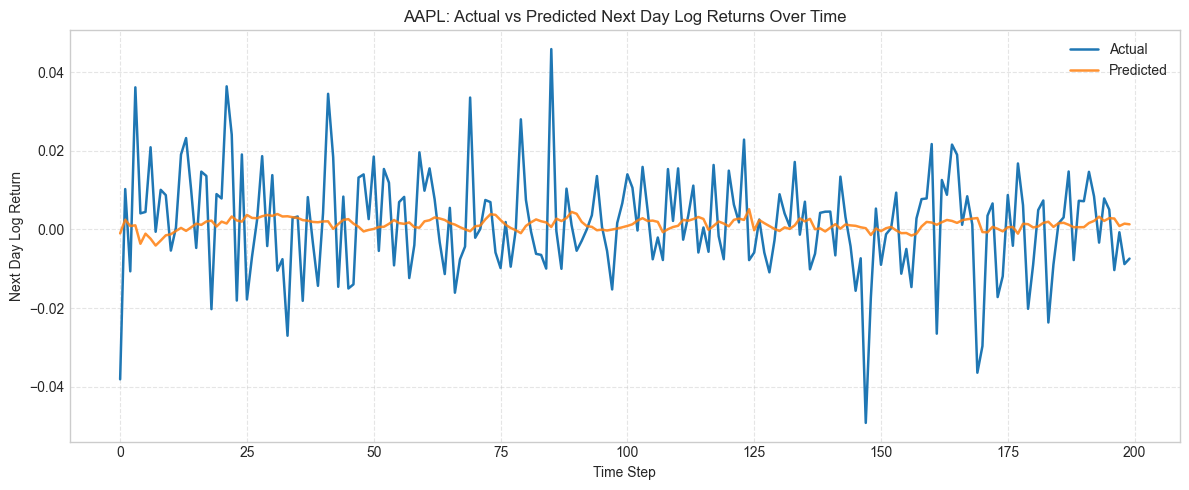

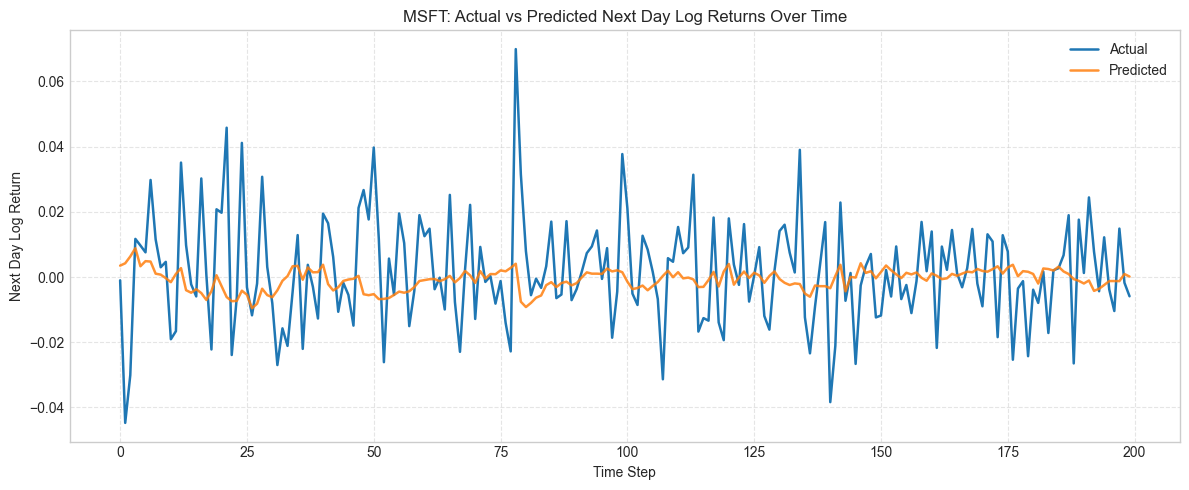

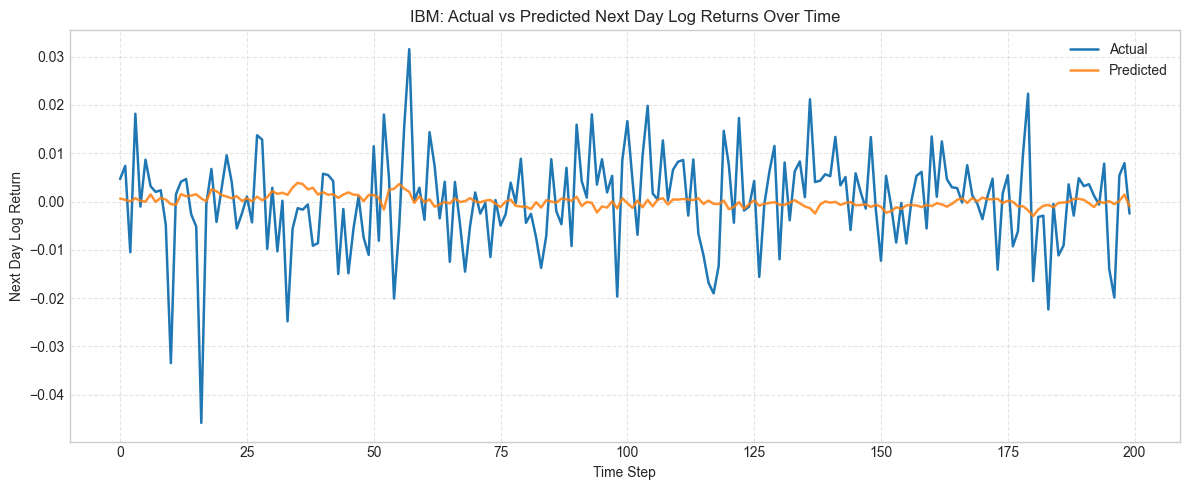

In [44]:
from plot_helpers import plot_actual_vs_predicted_returns

for ticker in tickers:
    run = single_stock_runs[ticker]
    plot_actual_vs_predicted_returns(
        run["y_test"],
        run["y_pred"],
        n_points=200,
        title=f"{ticker}: Actual vs Predicted Next Day Log Returns Over Time",
    )

Actually from the table, and also the plots,
it's clear to see that R^2 of all models are smaller than 0. Moreover, RMSE of each stocks are also slightly worser than the moving-average

=> Especially the LSTM directional accuracy is around only 50%, hence it's basically random-direction performance.



In [45]:
ticker = "AAPL"
run = single_stock_runs[ticker]

X_small = run["X_train"][:200]
y_small_true = run["y_train"][:200]

y_small_scaled = run["y_scaler"].transform(
    y_small_true.reshape(-1, 1)
).ravel()

config_debug = LSTMConfig(
    lstm_units=(64, 32),
    dense_units=(32, 16),
    dropout=0.0,
    recurrent_dropout=0.0,
    learning_rate=1e-3,
    loss="mse",
    output_units=1,
)

model_debug = build_lstm_model(
    input_shape=(X_small.shape[1], X_small.shape[2]),
    config=config_debug,
)

history_debug = model_debug.fit(
    X_small,
    y_small_scaled,
    epochs=200,
    batch_size=16,
    verbose=0,
    shuffle=False,
)

y_small_pred_scaled = model_debug.predict(X_small, verbose=0)
y_small_pred = run["y_scaler"].inverse_transform(
    y_small_pred_scaled.reshape(-1, 1)
).ravel()

print("Small true std:", y_small_true.std())
print("Small pred std:", y_small_pred.std())
print("Small pred min/max:", y_small_pred.min(), y_small_pred.max())

Small true std: 0.013836376
Small pred std: 0.0138887055
Small pred min/max: -0.048098892 0.039701134


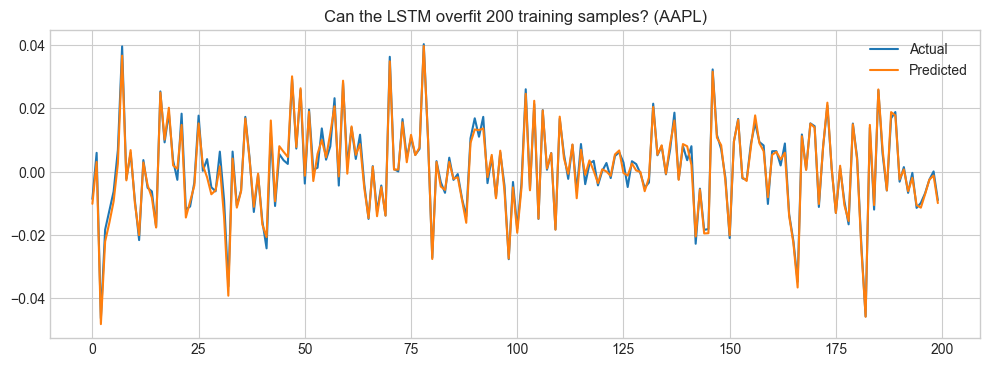

In [46]:
plt.figure(figsize=(12, 4))
plt.plot(y_small_true[:200], label="Actual")
plt.plot(y_small_pred[:200], label="Predicted")
plt.legend()
plt.title(f"Can the LSTM overfit 200 training samples? ({ticker})")
plt.show()

Comment: It's clear that from all the plots, LSTM architecture could learn the mapping from the input sequences to the target when the sample is VERY SMALL. 

In [47]:
print(f"DEBUG CHECK FOR: {ticker}")

print("\nShapes")
print("X_small shape:", X_small.shape)
print("y_small_true shape:", y_small_true.shape)
print("y_small_scaled shape:", y_small_scaled.shape)

print("\nX_small checks")
print("X_small contains NaN:", np.isnan(X_small).any())
print("X_small contains inf:", np.isinf(X_small).any())
print("X_small min/max:", X_small.min(), X_small.max())
print("X_small mean:", X_small.mean())
print("X_small std:", X_small.std())

print("\ny_small_true checks: real return scale")
print("y_small_true contains NaN:", np.isnan(y_small_true).any())
print("y_small_true contains inf:", np.isinf(y_small_true).any())
print("y_small_true mean:", y_small_true.mean())
print("y_small_true std:", y_small_true.std())
print("y_small_true min/max:", y_small_true.min(), y_small_true.max())
print("First 10 y_small_true:", y_small_true[:10])

print("\ny_small_scaled checks: target scale used by model")
print("y_small_scaled contains NaN:", np.isnan(y_small_scaled).any())
print("y_small_scaled contains inf:", np.isinf(y_small_scaled).any())
print("y_small_scaled mean:", y_small_scaled.mean())
print("y_small_scaled std:", y_small_scaled.std())
print("y_small_scaled min/max:", y_small_scaled.min(), y_small_scaled.max())
print("First 10 y_small_scaled:", y_small_scaled[:10])

DEBUG CHECK FOR: AAPL

Shapes
X_small shape: (200, 60, 17)
y_small_true shape: (200,)
y_small_scaled shape: (200,)

X_small checks
X_small contains NaN: False
X_small contains inf: False
X_small min/max: -3.625519 17.89761
X_small mean: 0.04561741
X_small std: 0.8483232

y_small_true checks: real return scale
y_small_true contains NaN: False
y_small_true contains inf: False
y_small_true mean: 0.0010979907
y_small_true std: 0.013836376
y_small_true min/max: -0.046264656 0.040294085
First 10 y_small_true: [-0.00858736  0.00598171 -0.04626466 -0.01827901 -0.01219976 -0.00621691
  0.00681996  0.03958744 -0.00224439  0.00591017]

y_small_scaled checks: target scale used by model
y_small_scaled contains NaN: False
y_small_scaled contains inf: False
y_small_scaled mean: 0.0028770256
y_small_scaled std: 0.77924997
y_small_scaled min/max: -2.6645367 2.210359
First 10 y_small_scaled: [-0.5425918   0.27792272 -2.6645367  -1.0884148  -0.7460379  -0.4090904
  0.32513216  2.1705616  -0.18536244  0.2

In [48]:
print("DEBUG TRAINING RESULT")

print("First loss:", history_debug.history["loss"][0])
print("Last loss :", history_debug.history["loss"][-1])
print("Min loss  :", min(history_debug.history["loss"]))

y_small_pred_scaled = model_debug.predict(X_small, verbose=0).ravel()

y_small_pred = run["y_scaler"].inverse_transform(
    y_small_pred_scaled.reshape(-1, 1)
).ravel()

print("\nScaled-space prediction")
print("y_small_scaled std:", y_small_scaled.std())
print("y_small_pred_scaled std:", y_small_pred_scaled.std())
print("y_small_pred_scaled min/max:", y_small_pred_scaled.min(), y_small_pred_scaled.max())

print("\nReal-return-space prediction")
print("y_small_true std:", y_small_true.std())
print("y_small_pred std:", y_small_pred.std())
print("y_small_pred min/max:", y_small_pred.min(), y_small_pred.max())

DEBUG TRAINING RESULT
First loss: 0.6478070020675659
Last loss : 0.013532675802707672
Min loss  : 0.013532675802707672

Scaled-space prediction
y_small_scaled std: 0.77924997
y_small_pred_scaled std: 0.782197
y_small_pred_scaled min/max: -2.767839 2.1769648

Real-return-space prediction
y_small_true std: 0.013836376
y_small_pred std: 0.0138887055
y_small_pred min/max: -0.048098892 0.039701134


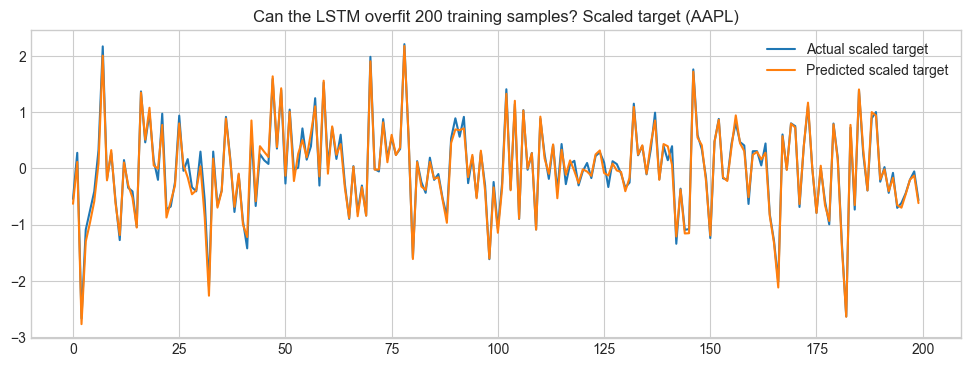

In [49]:
plt.figure(figsize=(12, 4))
plt.plot(y_small_scaled[:200], label="Actual scaled target")
plt.plot(y_small_pred_scaled[:200], label="Predicted scaled target")
plt.legend()
plt.title(f"Can the LSTM overfit 200 training samples? Scaled target ({ticker})")
plt.show()

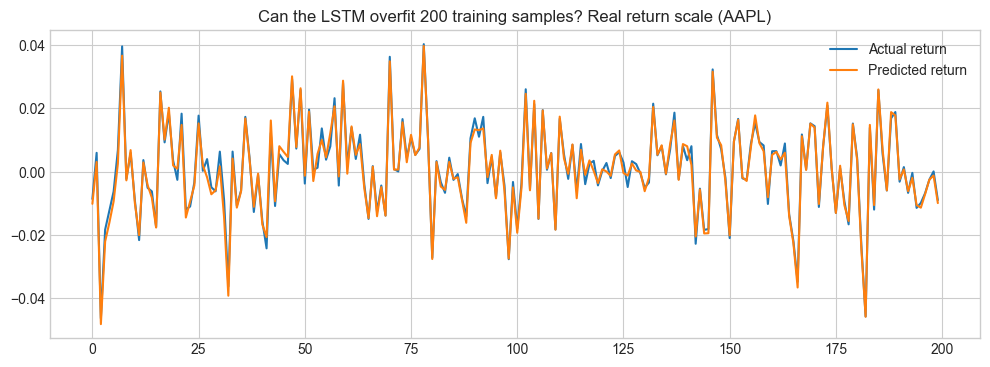

In [50]:
plt.figure(figsize=(12, 4))
plt.plot(y_small_true[:200], label="Actual return")
plt.plot(y_small_pred[:200], label="Predicted return")
plt.legend()
plt.title(f"Can the LSTM overfit 200 training samples? Real return scale ({ticker})")
plt.show()

## 14. Per-ticker directional benchmark inspired by Blaskowitz and Herwartz (2011)

The paper argues that directional forecasts should not be judged only by MSE or sign matching.
In this section, each ticker-specific LSTM is compared against directional benchmark rules: always-up, always-down, and the training-sample majority direction.


In [51]:
if RUN_POOLED_MODEL:
    from forecast_metrics import evaluate_directional_forecast

    directional_results = evaluate_directional_forecast(
        y_true=y_test,
        y_pred=y_pred,
        threshold=0.0,
    )

    directional_results


In [52]:
if RUN_POOLED_MODEL:
    always_up_results = evaluate_directional_forecast(
        y_true=y_test,
        y_pred=np.full_like(y_test, 1e-6),
        threshold=0.0,
        verbose=False,
    )

    always_down_results = evaluate_directional_forecast(
        y_true=y_test,
        y_pred=np.zeros_like(y_test),
        threshold=0.0,
        verbose=False,
    )

    benchmark_directional_df = pd.DataFrame(
        [
            {"model": "scaled_y_lstm", **directional_results},
            {"model": "always_up", **always_up_results},
            {"model": "always_down", **always_down_results},
        ]
    )

    benchmark_directional_df[[
        "model", "direction_accuracy", "balanced_accuracy", "hm_stat",
        "share_predicted_up", "mean_directional_value", "mean_always_up_value"
    ]]


In [53]:
from forecast_metrics import evaluate_directional_forecast

directional_benchmark_rows = []

for ticker in tickers:
    run = single_stock_runs[ticker]

    y_train_t = run["y_train"]
    y_test_t = run["y_test"]
    y_pred_t = run["y_pred"]

    # LSTM with threshold 0
    lstm_dir = evaluate_directional_forecast(
        y_true=y_test_t,
        y_pred=y_pred_t,
        threshold=0.0,
        verbose=False,
    )
    lstm_dir["ticker"] = ticker
    lstm_dir["model"] = "baseline_lstm_threshold_0"
    directional_benchmark_rows.append(lstm_dir)

    # Always-up benchmark
    always_up = evaluate_directional_forecast(
        y_true=y_test_t,
        y_pred=np.full_like(y_test_t, 1e-6),
        threshold=0.0,
        verbose=False,
    )
    always_up["ticker"] = ticker
    always_up["model"] = "always_up"
    directional_benchmark_rows.append(always_up)

    # Always-down benchmark
    always_down = evaluate_directional_forecast(
        y_true=y_test_t,
        y_pred=np.full_like(y_test_t, -1e-6),
        threshold=0.0,
        verbose=False,
    )
    always_down["ticker"] = ticker
    always_down["model"] = "always_down"
    directional_benchmark_rows.append(always_down)

    # Majority-direction benchmark based only on training data
    train_up_share = np.mean(y_train_t > 0)

    if train_up_share >= 0.5:
        majority_pred = np.full_like(y_test_t, 1e-6)
        majority_label = "majority_up"
    else:
        majority_pred = np.full_like(y_test_t, -1e-6)
        majority_label = "majority_down"

    majority = evaluate_directional_forecast(
        y_true=y_test_t,
        y_pred=majority_pred,
        threshold=0.0,
        verbose=False,
    )
    majority["ticker"] = ticker
    majority["model"] = majority_label
    directional_benchmark_rows.append(majority)

directional_benchmark_df = (
    pd.DataFrame(directional_benchmark_rows)
    .sort_values(["ticker", "model"])
    .reset_index(drop=True)
)

directional_benchmark_df[
    [
        "ticker",
        "model",
        "direction_accuracy",
        "balanced_accuracy",
        "hm_stat",
        "share_predicted_up",
        "mean_directional_value",
        "mean_always_up_value",
    ]
]


,ticker,model,direction_accuracy,balanced_accuracy,hm_stat,share_predicted_up,mean_directional_value,mean_always_up_value
0,AAPL,always_down,0.450798,0.500000,1.000000,0.000000,-0.001002,0.001002
1,AAPL,always_up,0.549202,0.500000,1.000000,1.000000,0.001002,0.001002
2,AAPL,baseline_lstm_threshold_0,0.515957,0.488761,0.977523,0.775266,0.000088,0.001002
3,AAPL,majority_up,0.549202,0.500000,1.000000,1.000000,0.001002,0.001002
4,IBM,always_down,0.437500,0.500000,1.000000,0.000000,-0.001134,0.001134
5,IBM,always_up,0.562500,0.500000,1.000000,1.000000,0.001134,0.001134
6,IBM,baseline_lstm_threshold_0,0.481383,0.493077,0.986153,0.405585,-0.000615,0.001134
7,IBM,majority_up,0.562500,0.500000,1.000000,1.000000,0.001134,0.001134
8,MSFT,always_down,0.457447,0.500000,1.000000,0.000000,-0.000964,0.000964
9,MSFT,always_up,0.542553,0.500000,1.000000,1.000000,0.000964,0.000964


these results show that the baseline LSTM is technically functioning but does not yet provide robust predictive improvement over simple benchmarks. This motivates the next modelling step: adding regime-aware information, such as HMM-derived bullish and bearish regime probabilities, to test whether market-state information can improve return prediction and directional performance.

## Visualizations:
### Scatterplot:

In [54]:
pred_df = pd.read_parquet(
    "outputs/predictions/baseline_lstm_predictions_all_tickers.parquet"
)

pred_df.head()

,ticker,input_end_date,target_date,split,y_true,y_pred,model
0,AAPL,2022-12-30,2023-01-03,test,-0.038122,-0.001012,baseline_lstm
1,AAPL,2023-01-03,2023-01-04,test,0.010261,0.002470,baseline_lstm
2,AAPL,2023-01-04,2023-01-05,test,-0.010661,0.000862,baseline_lstm
3,AAPL,2023-01-05,2023-01-06,test,0.036133,0.001035,baseline_lstm
4,AAPL,2023-01-06,2023-01-09,test,0.004080,-0.003651,baseline_lstm


In [55]:
!pip install seaborn==0.12.2

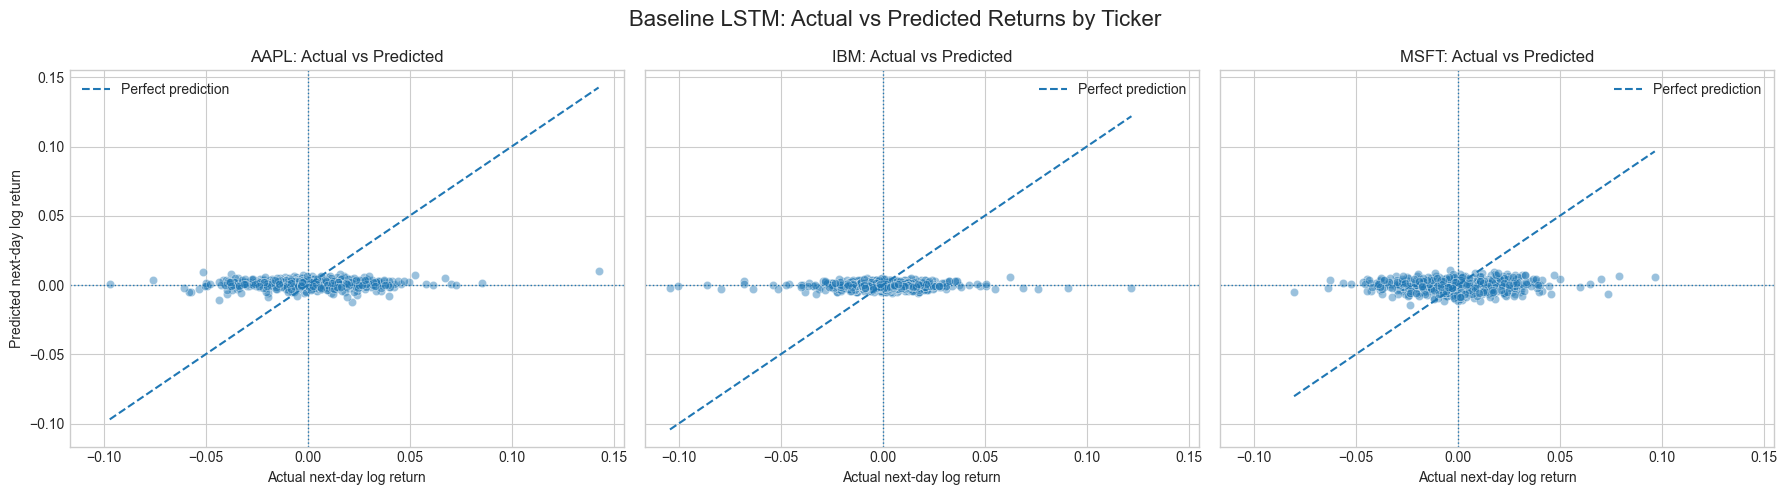

In [56]:
import seaborn as sns
tickers = sorted(pred_df["ticker"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(tickers),
    figsize=(6 * len(tickers), 5),
    sharex=True,
    sharey=True
)

if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    df_t = pred_df[pred_df["ticker"] == ticker].copy()

    sns.scatterplot(
        data=df_t,
        x="y_true",
        y="y_pred",
        alpha=0.45,
        s=35,
        ax=ax
    )

    # 45-degree reference line: perfect prediction
    min_val = min(df_t["y_true"].min(), df_t["y_pred"].min())
    max_val = max(df_t["y_true"].max(), df_t["y_pred"].max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        linewidth=1.5,
        label="Perfect prediction"
    )

    ax.axhline(0, linestyle=":", linewidth=1)
    ax.axvline(0, linestyle=":", linewidth=1)

    ax.set_title(f"{ticker}: Actual vs Predicted")
    ax.set_xlabel("Actual next-day log return")
    ax.set_ylabel("Predicted next-day log return")
    ax.legend()

plt.suptitle("Baseline LSTM: Actual vs Predicted Returns by Ticker", fontsize=16)
plt.tight_layout()
plt.show()


it's clear from the plot the there is the weak relationship between actual & predicted next-day log retuns. Most predictions are concentrated in a narrow range around zero, while the actual returns vary much more widely. The points do not follow the line clostly=> baseline LSTM strugles to predict the magnitude of daily returns=< Consitent with benchmark results: LSTM is no beeter the train-mean-return benchmark

### residual plot: $e_t = y_t - \hat{y}_t$

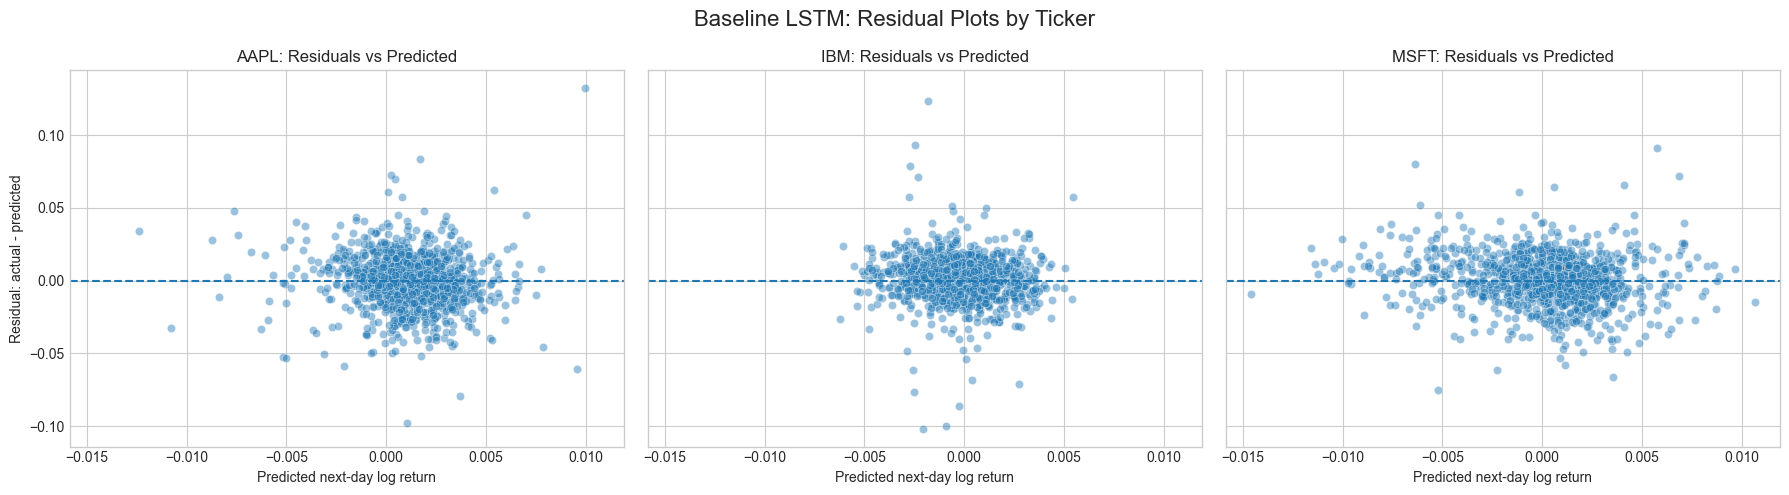

In [57]:
pred_df["residual"] = pred_df["y_true"] - pred_df["y_pred"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(tickers),
    figsize=(6 * len(tickers), 5),
    sharex=True,
    sharey=True
)
if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    df_t = pred_df[pred_df["ticker"] == ticker].copy()

    sns.scatterplot(
        data=df_t,
        x="y_pred",
        y="residual",
        alpha=0.45,
        s=35,
        ax=ax
    )

    ax.axhline(0, linestyle="--", linewidth=1.5)

    ax.set_title(f"{ticker}: Residuals vs Predicted")
    ax.set_xlabel("Predicted next-day log return")
    ax.set_ylabel("Residual: actual - predicted")

plt.suptitle("Baseline LSTM: Residual Plots by Ticker", fontsize=16)
plt.tight_layout()
plt.show()




It's clear that the errords are widely dispersed aroung -

=> The residuals are much larger than the range of predicted values, which suggests that the LSTM predictions are too conservative and do not capture the full volatility of next-day returns. There is no clear systematic pattern in the residuals, but the spread confirms that daily return prediction remains noisy and difficult.

### Residuals over time: useful because it's time-series data

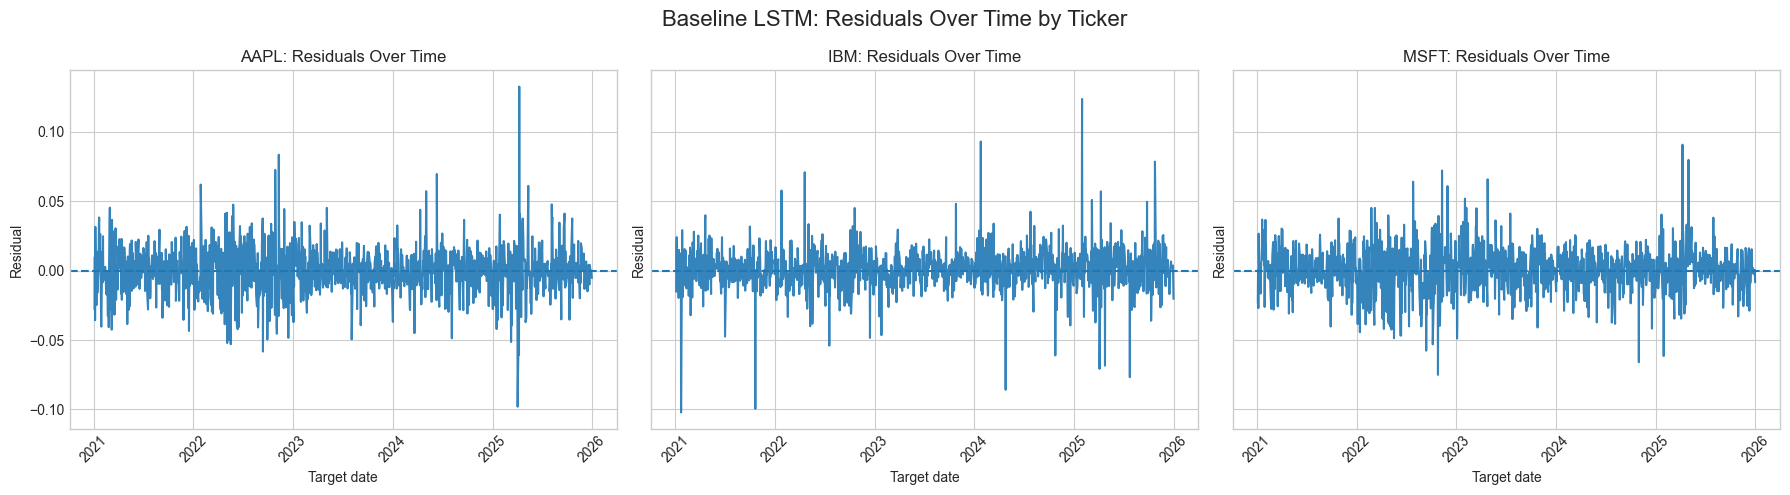

In [58]:
pred_df["target_date"] = pd.to_datetime(pred_df["target_date"])

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(tickers),
    figsize=(6 * len(tickers), 5),
    sharex=False,
    sharey=True
)

if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    df_t = pred_df[pred_df["ticker"] == ticker].sort_values("target_date").copy()

    ax.plot(
        df_t["target_date"],
        df_t["residual"],
        linewidth=1.5,
        alpha=0.9,
    )

    ax.axhline(0, linestyle="--", linewidth=1.5)

    ax.set_title(f"{ticker}: Residuals Over Time")
    ax.set_xlabel("Target date")
    ax.set_ylabel("Residual")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Baseline LSTM: Residuals Over Time by Ticker", fontsize=16)
plt.tight_layout()
plt.show()
